<a href="https://colab.research.google.com/github/nattapongbam/Rainfall-Forecasting-ChiangMai/blob/main/Transformer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

In [ ]:
df_init = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Project_Timeseries_Rainfall/Files_weather/weather_0001_not_normal_f1.csv')

In [ ]:
df_init.rename(columns = {'Unnamed: 0':'date'}, inplace = True)

In [ ]:
df_init['date_dt'] = pd.to_datetime(df_init['date'], format='%Y-%m-%d')
df_init['year'] = df_init['date_dt'].dt.year
df_init['month'] = df_init['date_dt'].dt.month
df_init['year_idx'] = df_init['year'] - df_init['year'].min()

df_init['month_sin'] = np.sin(2 * np.pi * df_init['month'] / 12)
df_init['month_cos'] = np.cos(2 * np.pi * df_init['month'] / 12)

In [ ]:
df_init['rain_1'] = df_init['rain'].shift(1)
df_init['rain_12'] = df_init['rain'].shift(12)
df_init['heat_index_1'] = df_init['heat_index'].shift(1)
df_init.dropna(inplace=True)

In [ ]:
df_init.columns

Index(['date', 'wind_dir', 'wind_speed', 'temp', 'heat_index', 'pressure',
       'preci', 'vis', 'rain', 'date_dt', 'year', 'month', 'year_idx',
       'month_sin', 'month_cos', 'rain_1', 'rain_12', 'heat_index_1'],
      dtype='object')

In [ ]:
train = df_init[:-12]
test = df_init[-12:]

train.reset_index(inplace=True)
test.reset_index(inplace=True)

train = train[['rain']]
test = test[['rain']]

In [ ]:
scaler = StandardScaler()
df_scaled_train = scaler.fit_transform(train)
df_scaled_test = scaler.transform(test)

In [ ]:
df_month = df_init[['month_sin', 'month_cos']]
# df_month = df_month.reindex()
df_month = df_month.reset_index(drop=True)

df_train_norm = pd.DataFrame(df_scaled_train, columns=train.columns)
df_test_norm = pd.DataFrame(df_scaled_test, columns=test.columns)

df1 = pd.concat([df_train_norm, df_test_norm], axis=0, ignore_index=True)
# df = pd.concat([df, df_month], axis=1, ignore_index=True)
df = pd.concat([df1, df_month], axis=1)

In [ ]:
df.columns

Index(['rain', 'month_sin', 'month_cos'], dtype='object')

In [ ]:
df.head()

,rain,month_sin,month_cos
0,-0.973845,0.500000,8.660254e-01
1,-0.973845,0.866025,5.000000e-01
2,-0.915949,1.000000,6.123234e-17
3,-0.620375,0.866025,-5.000000e-01
4,1.348087,0.500000,-8.660254e-01


# Model

In [ ]:
LOOKBACK = 24
HORIZON = 12
BATCH_SIZE = 12


def create_sequences(df, lookback=LOOKBACK, horizon=HORIZON):  #window slice
    # เลือกคอลัมน์ที่ต้องการ (เอา date ออก)
    features = ['rain', 'month_sin', 'month_cos']
    data = df[features].values

    X, y = [], []
    for i in range(len(data) - lookback - horizon + 1):
        X.append(data[i : i + lookback]) # ข้อมูลย้อนหลัง 24 เดือน ทุกตัวแปร
        y.append(data[i + lookback : i + lookback + horizon, 0]) # ทำนายเฉพาะ rain (index 0)
    return torch.FloatTensor(np.array(X)), torch.FloatTensor(np.array(y))



# สร้าง Sequences
# X_all, y_all = create_sequences(df) # แทนที่ df ด้วยตัวแปร DataFrame ของคุณ
X_all, y_all = create_sequences(df, lookback=LOOKBACK, horizon=HORIZON)

In [ ]:
X_train = X_all[:-12]
y_train = y_all[:-12]

X_test = X_all[-12:]
y_test = y_all[-12:]

In [ ]:
train_loader = DataLoader(TensorDataset(X_train, y_train), batch_size=BATCH_SIZE) #, shuffle=True

In [ ]:
nhead = 1
d_model = 8
patch_len = 3
dropout = 0.6

In [ ]:
class PatchTST(nn.Module): # Patch
    def __init__(self, num_channels=4, lookback=LOOKBACK, horizon=HORIZON, patch_len=patch_len, d_model=d_model):
        super().__init__()
        self.patch_len = patch_len
        self.stride = patch_len
        self.num_patches = lookback // patch_len

        # Encoding & Positional
        self.input_proj = nn.Linear(patch_len, d_model) #แปลงข้อมูลที่ group ตามจำนวน patch ให้กลายเป็น vecter d_model มิติ
        self.pos_embed = nn.Parameter(torch.zeros(1, self.num_patches, d_model))

        # Transformer Encoder (Small setup for 144 points)
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=nhead, dim_feedforward=d_model*2, dropout=dropout, batch_first=True
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=1)

        # Output Head
        self.head = nn.Linear(d_model * self.num_patches, horizon)

    def forward(self, x):
        B, L, C = x.shape
        x = x.permute(0, 2, 1).reshape(B * C, L) # [Batch * Channels, Lookback]
        x = x.unfold(-1, self.patch_len, self.stride) # [Batch * Channels, Patches, Patch_Len]

        x = self.input_proj(x) + self.pos_embed
        x = self.transformer(x)

        x = x.reshape(B * C, -1)
        x = self.head(x) # [Batch * Channels, Horizon]
        x = x.reshape(B, C, -1)
        return x[:, 0, :] # คืนค่าเฉพาะการทำนาย Rain (Channel 0)

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = PatchTST(num_channels=3, lookback=LOOKBACK, horizon=HORIZON).to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=0.001, weight_decay=0.05)
criterion = nn.MSELoss()

best_loss = float('inf')
patience = 10  # ถ้า Loss ไม่ดีขึ้นติดต่อกัน 10 รอบจะหยุดเทรน
counter = 0

for epoch in range(40): # เพิ่ม Epoch ได้เพราะเรามีระบบหยุดอัตโนมัติ
    model.train()
    total_loss = 0
    for bx, by in train_loader:
        bx, by = bx.to(device), by.to(device)
        optimizer.zero_grad()
        loss = criterion(model(bx), by)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    if (epoch + 1) % 20 == 0: print(f"Epoch {epoch+1}, Loss: {loss.item():.4f}")

    avg_loss = total_loss / len(train_loader)

    # เช็กว่า Loss ลดลงไหม ถ้าไม่ลดติดต่อกันเกิน 'patience' ให้หยุด
    if avg_loss < best_loss:
        best_loss = avg_loss
        counter = 0
        torch.save(model.state_dict(), 'best_model.pth') # เก็บตัวที่เก่งที่สุดไว้
    else:
        counter += 1
        if counter >= patience:
            print(f"Early stopping at epoch {epoch+1}")
            break

Epoch 20, Loss: 0.3550
Epoch 40, Loss: 0.0861


In [ ]:
# 1. หยิบ 12 ตัวอย่างสุดท้ายออกมาจาก X_train
X_train_last_year = X_train[-12:]

# 2. ส่งไปที่ Device (CPU/GPU) เพื่อให้พร้อมคำนวณในโมเดล
X_train_last_year = X_train_last_year.to(device)

# 3. อย่าลืมหา y_train_last_year เพื่อเอาไว้เทียบค่าจริงด้วยครับ
y_train_last_year = y_train[-12:]

In [ ]:
# 1. โหลด "สมอง" ตัวที่เก่งที่สุดที่บันทึกไว้ก่อนหน้านี้กลับมา
model.load_state_dict(torch.load('best_model.pth'))
model.eval()

with torch.no_grad():
    # 2. ทำนายข้อมูลชุดเดิมอีกครั้งด้วยโมเดลที่ดีที่สุด
    train_preds = model(X_train_last_year).cpu().numpy()

    # 3. คำนวณ Metrics ใหม่
    train_mae = mean_absolute_error(y_train_last_year, train_preds)
    train_mse = mean_squared_error(y_train_last_year, train_preds)
    print(f"--- Updated Best Model Metrics ---")
    print(f"MSE : {train_mse:.4f}")

--- Updated Best Model Metrics ---
MSE : 0.8093


In [ ]:
# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# model = PatchTST(num_channels=3, lookback=LOOKBACK, horizon=HORIZON).to(device)
# optimizer = torch.optim.AdamW(model.parameters(), lr=0.05, weight_decay=0.1)
# criterion = nn.MSELoss()

# for epoch in range(20):
#     model.train()
#     for bx, by in train_loader:
#         bx, by = bx.to(device), by.to(device)
#         optimizer.zero_grad()
#         loss = criterion(model(bx), by)
#         loss.backward()
#         optimizer.step()
#     if (epoch + 1) % 20 == 0: print(f"Epoch {epoch+1}, Loss: {loss.item():.4f}")

# Train

In [ ]:
def get_original_scale(preds_norm, scaler):
    # preds_norm คือผลลัพธ์จากโมเดลมิติ [Samples, 12]

    # 1. ยืดข้อมูลออกเป็นเส้นเดียวเพื่อเข้า Scaler
    flat_preds = preds_norm.flatten()

    # 2. สร้าง Matrix หลอกขนาด [N, 8]
    # ใช้ scaler.n_features_in_ เพื่อดึงค่า 8 ออกมาโดยอัตโนมัติจากตัว scaler เอง
    num_features = scaler.n_features_in_
    dummy = np.zeros((len(flat_preds), num_features))

    # 3. ใส่ค่าที่ทำนายได้ลงในคอลัมน์แรก (ตำแหน่งของ 'rain')
    dummy[:, 0] = flat_preds

    # 4. ใช้ scaler ตัวเดิมที่โหลดมาจาก joblib ทำการ inverse_transform
    unscaled_dummy = scaler.inverse_transform(dummy)

    # 5. ดึงเฉพาะคอลัมน์แรกกลับมา และจัดรูปทรงให้เป็น [Samples, 12] เหมือนเดิม
    return unscaled_dummy[:, 0].reshape(preds_norm.shape)

In [ ]:
model.eval()
with torch.no_grad():
    # ดึงข้อมูล 12 ชุดสุดท้ายของ Training Set (ประมาณ 1 ปี)
    X_train_last_year = X_train[-12:].to(device)
    y_train_last_year = y_train[-12:].numpy()

    # ให้โมเดลลองพยากรณ์ข้อมูลที่มัน "เคยเห็นแล้ว"
    train_preds = model(X_train_last_year).cpu().numpy()  #y_pred_train

    # คำนวณ Metrics ของ Training Set ปีสุดท้าย
    train_mae = mean_absolute_error(y_train_last_year, train_preds)
    train_mse = mean_squared_error(y_train_last_year, train_preds)
    train_rmse = np.sqrt(mean_squared_error(y_train_last_year, train_preds))
    # train_r2 = r2_score(y_train_last_year.flatten(), train_preds.flatten())
    train_r2 = r2_score(y_train_last_year, train_preds)

    print(f"--- Training Set Metrics (Last Year) ---")
    print(f"MSE : {train_mse:.4f}")
    print(f"MAE: {train_mae:.4f} | RMSE: {train_rmse:.4f} | R2: {train_r2:.4f}")

--- Training Set Metrics (Last Year) ---
MSE : 0.8093
MAE: 0.6037 | RMSE: 0.8996 | R2: 0.5248


In [ ]:
model.eval()
with torch.no_grad():
    # 1. เตรียมข้อมูลปีสุดท้ายของ Training Set (เหมือนที่คุณทำ)
    X_train_last_year = X_train[-12:].to(device)
    y_train_last_year_norm = y_train[-12:].numpy()

    # 2. พยากรณ์ (ผลลัพธ์ยังเป็นหน่วย Normalized)
    train_preds_norm = model(X_train_last_year).cpu().numpy()

    # 3. แปลงกลับเป็นหน่วยจริง (มิลลิเมตร) ด้วยฟังก์ชัน get_original_scale
    # หมายเหตุ: ต้องมั่นใจว่าในฟังก์ชัน get_original_scale แก้จากเลข 4 เป็น 8 แล้วนะครับ
    train_preds_mm = get_original_scale(train_preds_norm, scaler)
    y_train_last_year_mm = get_original_scale(y_train_last_year_norm, scaler)

    # 4. คำนวณ Metrics ในหน่วยจริง
    mae_mm = mean_absolute_error(y_train_last_year_mm, train_preds_mm)
    mse_mm = mean_squared_error(y_train_last_year_mm, train_preds_mm)
    rmse_mm = np.sqrt(mean_squared_error(y_train_last_year_mm, train_preds_mm))
    r2_mm = r2_score(y_train_last_year_mm, train_preds_mm)

    print(f"--- Training Set Metrics (Last Year - Original Scale) ---")
    print(f"MSE:  {mse_mm:.2f} mm")
    print("---------------")
    print(f"MAE:  {mae_mm:.2f} mm")
    print(f"RMSE: {rmse_mm:.2f} mm")
    print(f"R2: {r2_mm:.2f} ")
    # print(f"R2:   {train_r2:.4f} (ค่าเดิม)")

--- Training Set Metrics (Last Year - Original Scale) ---
MSE:  8.72 mm
---------------
MAE:  1.98 mm
RMSE: 2.95 mm
R2: 0.52 


# Test

In [ ]:
model.eval()
with torch.no_grad():
    preds = model(X_test.to(device)).cpu().numpy()
    actual = y_test.numpy()

    # Metrics
    mae = mean_absolute_error(actual, preds)
    rmse = np.sqrt(mean_squared_error(actual, preds))
    r2 = r2_score(actual.flatten(), preds.flatten())

    print(f"\n--- Metrics (Normalized Scale) ---")
    print(f"MAE: {mae:.4f} | RMSE: {rmse:.4f} | R2: {r2:.4f}")


--- Metrics (Normalized Scale) ---
MAE: 0.6211 | RMSE: 0.8641 | R2: 0.4571


In [ ]:
# --- ส่วนการวัดผลในหน่วยจริง ---
model.eval()
with torch.no_grad():
    y_pred_norm = model(X_test.to(device)).cpu().numpy()
    y_true_norm = y_test.numpy()

    # แปลงกลับเป็นหน่วยมิลลิเมตร
    y_pred_mm = get_original_scale(y_pred_norm, scaler)   #y_pred_test
    y_true_mm = get_original_scale(y_true_norm, scaler)   #y_true_test

    # คำนวณความผิดพลาดจริง
    mae_mm = mean_absolute_error(y_true_mm, y_pred_mm)
    mse_mm = mean_squared_error(y_true_mm, y_pred_mm)
    rmse_mm = np.sqrt(mean_squared_error(y_true_mm, y_pred_mm))
    r2_mm = r2_score(y_true_mm, y_pred_mm)

    print(f"--- Metrics (Original Scale - mm) ---")
    print(f"MSE:  {mse_mm:.2f} mm")
    print("--------------")
    print(f"MAE:  {mae_mm:.2f} mm")
    print(f"RMSE: {rmse_mm:.2f} mm")
    print(f"R2: {r2_mm:.2f} ")

--- Metrics (Original Scale - mm) ---
MSE:  8.04 mm
--------------
MAE:  2.04 mm
RMSE: 2.84 mm
R2: 0.46 


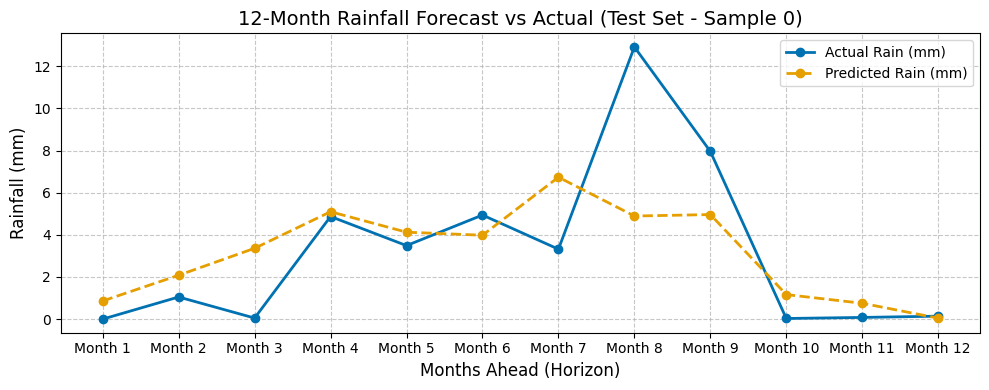

In [ ]:
import matplotlib.pyplot as plt

# เลือก Sample ที่ต้องการดู (เปลี่ยนตัวเลขได้ เช่น 0 คือชุดแรกของ Test Set, -1 คือชุดสุดท้าย)
sample_idx = 0

actual_12_months = y_true_mm[sample_idx]
predicted_12_months = y_pred_mm[sample_idx]

plt.figure(figsize=(10, 4))
plt.plot(actual_12_months, label='Actual Rain (mm)', color='#0072B2', marker='o', linewidth=2)
plt.plot(predicted_12_months, label='Predicted Rain (mm)', color='#E69F00', marker='o', linewidth=2, linestyle='--')

plt.title(f'12-Month Rainfall Forecast vs Actual (Test Set - Sample {sample_idx})', fontsize=14)
plt.xlabel('Months Ahead (Horizon)', fontsize=12)
plt.ylabel('Rainfall (mm)', fontsize=12)
plt.xticks(range(12), [f'Month {i+1}' for i in range(12)]) # ปรับแกน X ให้เป็นเดือนที่ 1-12
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [ ]:
from torch.utils.data import DataLoader, TensorDataset

# 1. นำ X_test และ y_test ที่คุณมีอยู่แล้วมาสร้างเป็น Dataset
# (X_test, y_test ต้องเป็น Torch Tensor นะครับ)
test_dataset = TensorDataset(X_test, y_test)

# 2. สร้าง DataLoader สำหรับ Test Set
# - ใช้ BATCH_SIZE เดียวกับตอนเทรน (เช่น 16)
# - shuffle=False สำคัญมาก! เพื่อให้ข้อมูลเรียงตามลำดับเวลาจากอดีตไปอนาคต
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print("นิยาม test_loader เรียบร้อยแล้ว!")

นิยาม test_loader เรียบร้อยแล้ว!


## ลอง

In [ ]:
!pip install sktime

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates # Import mdates
from sktime.utils.plotting import plot_series

# fh_train = np.arange(-len(train['rain']) + 1, 1)
# y_fitted_train = gscv.predict(fh=fh_train)

# plt.figure(figsize=(15, 6))
# plot_series(train['rain'], y_fitted_train, labels=["Actual (Train)", "Fitted (Holt-Winters)"])
# plt.title("Actual vs Train Fitted")
# ax = plt.gca() # Get the current axes
# ax.xaxis.set_major_locator(mdates.YearLocator())
# plt.grid(True)
# plt.show()

test

In [ ]:
X_train1 = X_train.to(device)
# y_train1 = y_train.numpy()

y_pred_vi = model(X_train1).cpu().detach().numpy()

y_vi = df_init['rain']

In [ ]:
y_denorm = get_original_scale(y_pred_vi, scaler)
y_denorm = y_denorm[:, 0]
df_denorm = pd.DataFrame(y_denorm, columns=['rain'])

<Figure size 1500x600 with 0 Axes>

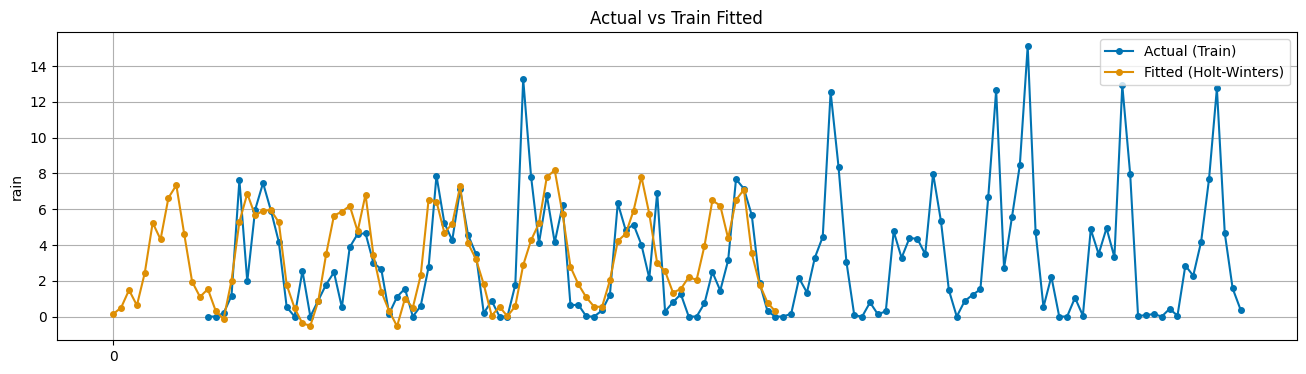

In [ ]:
plt.figure(figsize=(15, 6))
plot_series(y_vi, df_denorm, labels=["Actual (Train)", "Fitted (Holt-Winters)"])
plt.title("Actual vs Train Fitted")
ax = plt.gca() # Get the current axes
ax.xaxis.set_major_locator(mdates.YearLocator())
plt.grid(True)
plt.show()

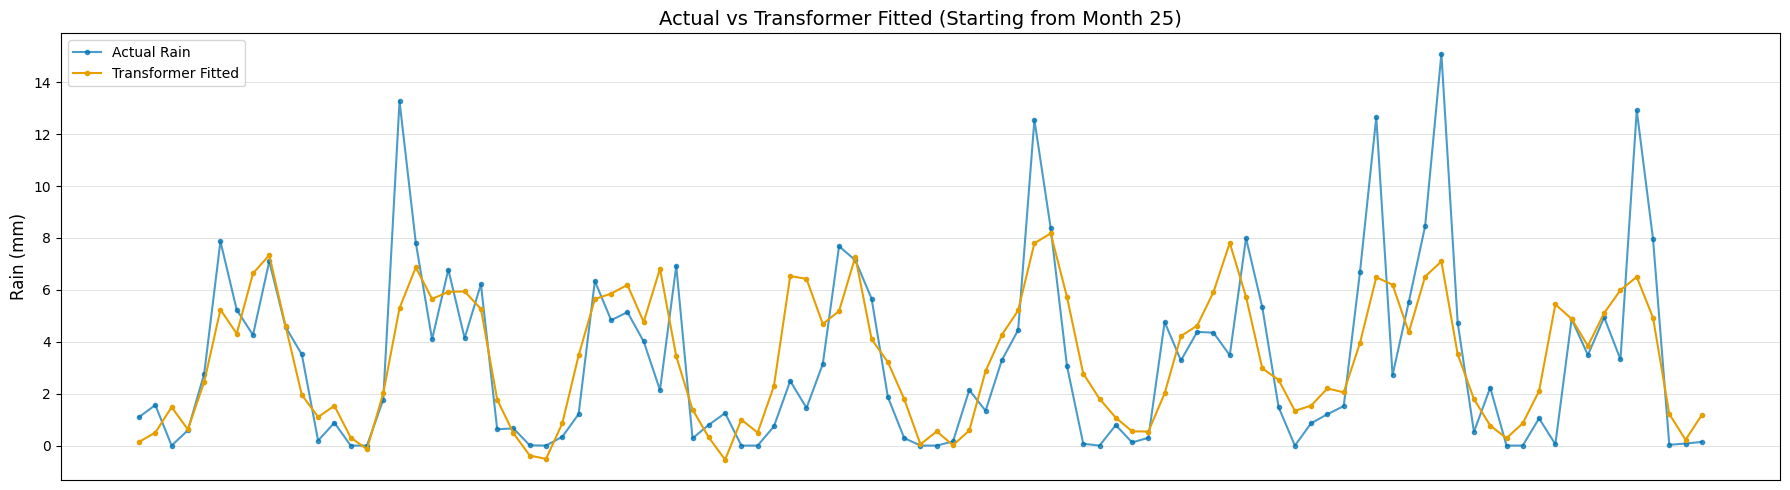

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np
import pandas as pd

# 1. เตรียมโมเดลเพื่อการพยากรณ์
model.eval()
with torch.no_grad():
    # ส่ง X_all เข้าโมเดลเพื่อดูผลลัพธ์ทั้งหมด
    # shape ของ X_all คือ [Samples, LOOKBACK, 4]
    y_all_pred_norm = model(X_all.to(device)).cpu().numpy()

# 2. แปลงค่ากลับเป็นหน่วยมิลลิเมตร (mm)
# เราจะเลือกเฉพาะการพยากรณ์ก้าวแรก (index 0 ของ HORIZON) เพื่อสร้างเส้นต่อเนื่อง
y_pred_first_step = y_all_pred_norm[:, 0]
y_true_first_step = y_all[:, 0].numpy()

# ใช้ฟังก์ชัน get_original_scale ที่เรามี (ต้องมั่นใจว่า num_features ในฟังก์ชันตรงกับ 4 หรือ 8 ที่คุณใช้)
y_pred_mm = get_original_scale(y_pred_first_step.reshape(-1, 1), scaler).flatten()
y_true_mm = get_original_scale(y_true_first_step.reshape(-1, 1), scaler).flatten()

# 3. จัดตำแหน่ง Index ให้ถูกต้อง
# โมเดลจะเริ่มทำนายได้ ณ จุดเวลาที่ LOOKBACK (ในเคสของคุณคือเดือนที่ 25)
prediction_index = df.index[LOOKBACK : LOOKBACK + len(y_pred_mm)]

# 4. พล็อตกราฟสไตล์ที่คุณต้องการ
plt.figure(figsize=(18, 5))

# เส้นข้อมูลจริง (Actual)
plt.plot(prediction_index, y_true_mm,
         label='Actual Rain', color='#0072B2', marker='o', markersize=3, alpha=0.7)

# เส้นที่โมเดลพยากรณ์ (Predicted)
plt.plot(prediction_index, y_pred_mm,
         label='Transformer Fitted', color='#E69F00', marker='o', markersize=3)

# ตกแต่งกราฟให้สวยงามแบบต้นฉบับ
plt.title(f'Actual vs Transformer Fitted (Starting from Month {LOOKBACK+1})', fontsize=14)
plt.ylabel('Rain (mm)', fontsize=12)
plt.grid(True, which='both', linestyle='-', linewidth=0.5, alpha=0.5)
plt.legend(loc='upper left')

# จัดรูปแบบแกน X ให้แสดงเป็นรายปี
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.gca().xaxis.set_major_locator(mdates.YearLocator())

plt.tight_layout()
plt.show()